# Notebook 05 — Cross-Day Concept Drift Analysis
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Purpose
This notebook **empirically demonstrates concept drift** in network intrusion detection.

Concept drift occurs when the statistical relationship between features and labels changes over time.
In cybersecurity, this means attack patterns evolve — a model trained on historical attacks
may fail to detect new attack variants even within a short time window.

### Experimental Design
- **RF Training data**: Monday + Tuesday only (BENIGN, FTP-Patator, SSH-Patator)
- **IF Training data**: Monday BENIGN only (learns normal traffic boundary)
- **Test data**: Each remaining day evaluated **independently**
- **Metric tracked**: Attack Recall, F1-macro, FPR across days

This design isolates the temporal generalisation question:
*"How does a model trained on early-week attacks perform on later-week attacks?"*

### Why This Matters
> The CICIDS2017 dataset spans 5 days with different attack types each day.
> A model trained on Monday–Tuesday attacks (FTP/SSH-Patator) has **never seen**
> DoS, Web Attacks, PortScan, or DDoS. Performance should degrade as we test
> further from the training distribution — this is concept drift in action.


---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, warnings, time, gc

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROCESSED_DIR = '../data/processed'
RESULTS_DIR   = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load saved preprocessing artifacts
scaler        = joblib.load(f'{PROCESSED_DIR}/scaler.pkl')
le            = joblib.load(f'{PROCESSED_DIR}/label_encoder.pkl')
feature_names = joblib.load(f'{PROCESSED_DIR}/feature_names.pkl')

print("Environment ready.")
print(f"  Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Environment ready.
  Label encoding: {'ATTACK': np.int64(0), 'BENIGN': np.int64(1)}


---
## 2. Load Each Day Independently

Each day is loaded as a separate dataset to enable per-day evaluation.
This is the key structural difference from Notebooks 02–04 which used a combined temporal split.


In [2]:
DATA_DIR = '../data'

DAY_FILES = {
    'Monday':     ['Monday-WorkingHours.pcap_ISCX.csv'],
    'Tuesday':    ['Tuesday-WorkingHours.pcap_ISCX.csv'],
    'Wednesday':  ['Wednesday-workingHours.pcap_ISCX.csv'],
    'Thursday':   ['Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
                   'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'],
    'Friday':     ['Friday-WorkingHours-Morning.pcap_ISCX.csv',
                   'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
                   'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'],
}

def load_day(files, data_dir):
    dfs = []
    for f in files:
        df = pd.read_csv(os.path.join(data_dir, f))
        df.columns = df.columns.str.strip()
        dfs.append(df)
    combined = pd.concat(dfs, axis=0, ignore_index=True)
    combined.replace([np.inf, -np.inf], np.nan, inplace=True)
    combined.dropna(inplace=True)
    combined['BinaryLabel'] = combined['Label'].apply(
        lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK'
    )
    return combined

print("Loading each day...")
days = {}
for day, files in DAY_FILES.items():
    days[day] = load_day(files, DATA_DIR)
    n_attack = (days[day]['BinaryLabel'] == 'ATTACK').sum()
    attacks = days[day][days[day]['BinaryLabel']=='ATTACK']['Label'].unique()
    print(f"  {day:<12}: {len(days[day]):>8,} rows | {n_attack:>7,} attacks | {list(attacks)}")


Loading each day...
  Monday      :  529,481 rows |       0 attacks | []
  Tuesday     :  445,645 rows |  13,832 attacks | ['FTP-Patator', 'SSH-Patator']
  Wednesday   :  691,406 rows | 251,723 attacks | ['DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed']
  Thursday    :  458,626 rows |   2,216 attacks | ['Web Attack � Brute Force', 'Web Attack � XSS', 'Web Attack � Sql Injection', 'Infiltration']
  Friday      :  702,718 rows | 288,785 attacks | ['Bot', 'PortScan', 'DDoS']


---
## 3. Train Baseline Models on Monday + Tuesday

### Training Set Choice
Monday + Tuesday is the **minimal training window** — the first two days of captures.
- Monday: BENIGN only — establishes normal baseline
- Tuesday: FTP-Patator + SSH-Patator — first attack types introduced

This intentionally limits the model's knowledge to motivate the drift analysis.


In [3]:
# Combine Mon + Tue for RF training
df_train = pd.concat([days['Monday'], days['Tuesday']], axis=0, ignore_index=True)

X_train_df = df_train[feature_names].astype(np.float32)
y_train_enc = le.transform(df_train['BinaryLabel'])

# Fit a fresh scaler on this training subset
drift_scaler = StandardScaler()
X_train_scaled = drift_scaler.fit_transform(X_train_df).astype(np.float32)

# Monday BENIGN only — for Isolation Forest
df_monday_benign = days['Monday'][days['Monday']['BinaryLabel'] == 'BENIGN']
X_mon_benign = drift_scaler.transform(
    df_monday_benign[feature_names].astype(np.float32)
).astype(np.float32)

del X_train_df
gc.collect()

print("Training RF on Monday + Tuesday...")
rf_drift = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'
)
t0 = time.time()
rf_drift.fit(X_train_scaled, y_train_enc)
print(f"  RF trained in {time.time()-t0:.1f}s on {len(y_train_enc):,} rows")

print("\nTraining IF on Monday BENIGN only...")
if_drift = IsolationForest(
    n_estimators=100, contamination=0.20, random_state=42, n_jobs=-1
)
t0 = time.time()
if_drift.fit(X_mon_benign)
print(f"  IF trained in {time.time()-t0:.1f}s on {len(X_mon_benign):,} BENIGN rows")

print("\nTraining attack types seen:")
print(f"  {df_train['Label'].value_counts().to_dict()}")


Training RF on Monday + Tuesday...
  RF trained in 10.7s on 975,126 rows

Training IF on Monday BENIGN only...
  IF trained in 2.1s on 529,481 BENIGN rows

Training attack types seen:
  {'BENIGN': 961294, 'FTP-Patator': 7935, 'SSH-Patator': 5897}


---
## 4. Evaluate on Each Day Independently

Each day is scaled using the **drift_scaler** (fitted on Mon+Tue training data)
and both models are evaluated. Results are collected into a drift table.

> **Note**: Monday and Tuesday are *in-distribution* (training data).
> Wednesday, Thursday, Friday are *out-of-distribution* — this is where drift becomes visible.


In [4]:
drift_results = []

TEST_DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

for day in TEST_DAYS:
    df_day = days[day]
    X_day = drift_scaler.transform(
        df_day[feature_names].astype(np.float32)
    ).astype(np.float32)
    y_day = le.transform(df_day['BinaryLabel'])

    has_attacks = (y_day == 0).sum() > 0

    # ── Random Forest ──
    y_pred_rf = rf_drift.predict(X_day)
    rf_attack_recall = recall_score(y_day, y_pred_rf, pos_label=0, zero_division=0)
    rf_f1            = f1_score(y_day, y_pred_rf, average='macro', zero_division=0)
    rf_accuracy      = accuracy_score(y_day, y_pred_rf)
    # FPR
    benign_idx = y_day == 1
    rf_fpr = (y_pred_rf[benign_idx] == 0).sum() / benign_idx.sum() if benign_idx.sum() > 0 else 0

    # ── Isolation Forest ──
    pred_if  = if_drift.predict(X_day)
    y_pred_if = np.where(pred_if == 1, 1, 0)
    if_attack_recall = recall_score(y_day, y_pred_if, pos_label=0, zero_division=0)
    if_f1            = f1_score(y_day, y_pred_if, average='macro', zero_division=0)
    if_fpr = (y_pred_if[benign_idx] == 0).sum() / benign_idx.sum() if benign_idx.sum() > 0 else 0

    attack_types = list(df_day[df_day['BinaryLabel']=='ATTACK']['Label'].unique())

    drift_results.append({
        'Day':            day,
        'Rows':           len(df_day),
        'Attack Types':   ', '.join(attack_types) if attack_types else 'None (BENIGN only)',
        'RF Attack Recall': round(rf_attack_recall, 4),
        'RF F1-macro':    round(rf_f1, 4),
        'RF FPR':         round(rf_fpr, 4),
        'IF Attack Recall': round(if_attack_recall, 4),
        'IF F1-macro':    round(if_f1, 4),
        'IF FPR':         round(if_fpr, 4),
    })

    del X_day
    gc.collect()

    print(f"  {day:<12} | RF Recall={rf_attack_recall:.3f} F1={rf_f1:.3f} FPR={rf_fpr:.3f}"
          f" | IF Recall={if_attack_recall:.3f} F1={if_f1:.3f} FPR={if_fpr:.3f}")

drift_df = pd.DataFrame(drift_results)
print("\n" + "="*70)
print(drift_df[['Day','Attack Types','RF Attack Recall','IF Attack Recall','RF FPR','IF FPR']].to_string(index=False))


  Monday       | RF Recall=0.000 F1=1.000 FPR=0.000 | IF Recall=0.000 F1=0.445 FPR=0.200
  Tuesday      | RF Recall=1.000 F1=1.000 FPR=0.000 | IF Recall=0.213 F1=0.466 FPR=0.203
  Wednesday    | RF Recall=0.000 F1=0.389 FPR=0.000 | IF Recall=0.692 F1=0.737 FPR=0.212
  Thursday     | RF Recall=0.000 F1=0.499 FPR=0.000 | IF Recall=0.064 F1=0.453 FPR=0.174
  Friday       | RF Recall=0.000 F1=0.371 FPR=0.000 | IF Recall=0.288 F1=0.504 FPR=0.262

      Day                                                                         Attack Types  RF Attack Recall  IF Attack Recall  RF FPR  IF FPR
   Monday                                                                   None (BENIGN only)               0.0            0.0000     0.0  0.1997
  Tuesday                                                             FTP-Patator, SSH-Patator               1.0            0.2131     0.0  0.2032
Wednesday                 DoS slowloris, DoS Slowhttptest, DoS Hulk, DoS GoldenEye, Heartbleed               0.0 

---
## 5. Concept Drift Visualisation

The plots below show how model performance changes across days.
A clear **downward trend** in attack recall from Tuesday onwards demonstrates concept drift:
the models are increasingly unable to detect attack types they were not trained on.


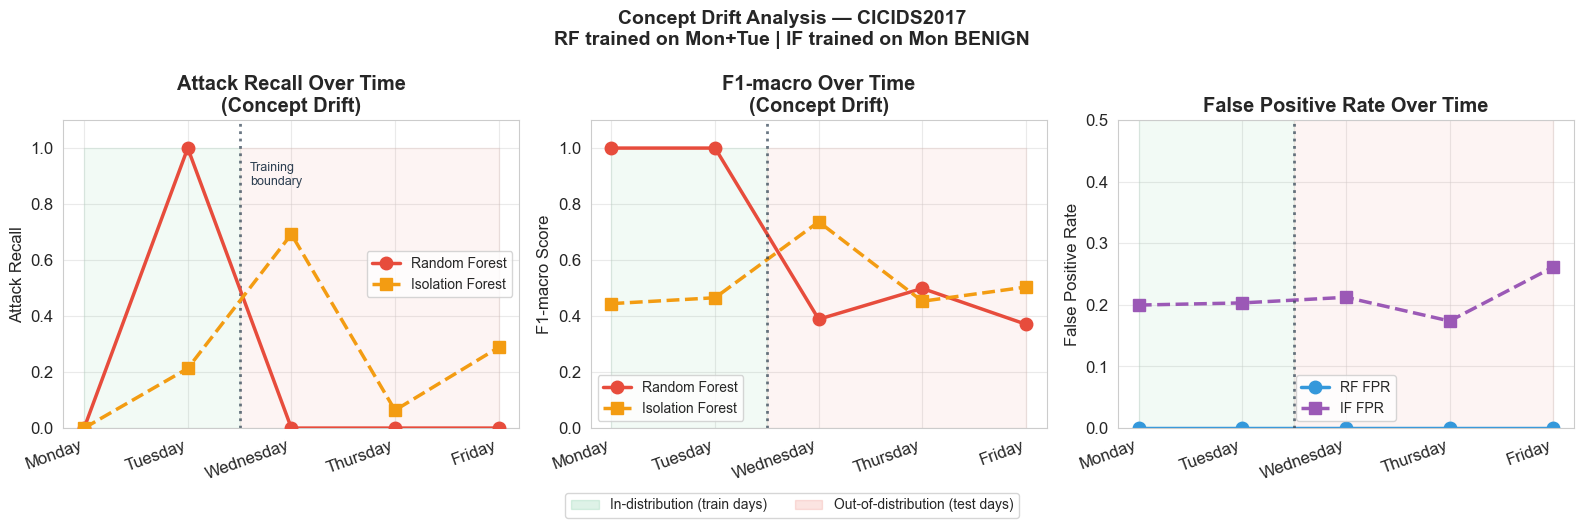

Saved: 11_concept_drift_analysis.png + 11_concept_drift_table.csv


In [5]:
days_x = drift_df['Day'].tolist()
x = range(len(days_x))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Attack Recall ──
axes[0].plot(x, drift_df['RF Attack Recall'], 'o-', color='#e74c3c',
             lw=2.5, ms=9, label='Random Forest', zorder=3)
axes[0].plot(x, drift_df['IF Attack Recall'], 's--', color='#f39c12',
             lw=2.5, ms=9, label='Isolation Forest', zorder=3)
axes[0].axvline(x=1.5, color='#2c3e50', linestyle=':', lw=2, alpha=0.7)
axes[0].text(1.6, 0.95, 'Training\nboundary', fontsize=9, color='#2c3e50', va='top')
axes[0].fill_betweenx([0, 1], 0, 1.5, alpha=0.06, color='#27ae60')
axes[0].fill_betweenx([0, 1], 1.5, 4, alpha=0.06, color='#e74c3c')
axes[0].set_xticks(x); axes[0].set_xticklabels(days_x, rotation=20, ha='right')
axes[0].set_ylabel('Attack Recall')
axes[0].set_title('Attack Recall Over Time\n(Concept Drift)', fontweight='bold')
axes[0].set_ylim(0, 1.1); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.4)

# ── F1-macro ──
axes[1].plot(x, drift_df['RF F1-macro'], 'o-', color='#e74c3c', lw=2.5, ms=9, label='Random Forest')
axes[1].plot(x, drift_df['IF F1-macro'], 's--', color='#f39c12', lw=2.5, ms=9, label='Isolation Forest')
axes[1].axvline(x=1.5, color='#2c3e50', linestyle=':', lw=2, alpha=0.7)
axes[1].fill_betweenx([0, 1], 0, 1.5, alpha=0.06, color='#27ae60')
axes[1].fill_betweenx([0, 1], 1.5, 4, alpha=0.06, color='#e74c3c')
axes[1].set_xticks(x); axes[1].set_xticklabels(days_x, rotation=20, ha='right')
axes[1].set_ylabel('F1-macro Score')
axes[1].set_title('F1-macro Over Time\n(Concept Drift)', fontweight='bold')
axes[1].set_ylim(0, 1.1); axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.4)

# ── False Positive Rate ──
axes[2].plot(x, drift_df['RF FPR'], 'o-', color='#3498db', lw=2.5, ms=9, label='RF FPR')
axes[2].plot(x, drift_df['IF FPR'], 's--', color='#9b59b6', lw=2.5, ms=9, label='IF FPR')
axes[2].axvline(x=1.5, color='#2c3e50', linestyle=':', lw=2, alpha=0.7)
axes[2].fill_betweenx([0, 1], 0, 1.5, alpha=0.06, color='#27ae60')
axes[2].fill_betweenx([0, 1], 1.5, 4, alpha=0.06, color='#e74c3c')
axes[2].set_xticks(x); axes[2].set_xticklabels(days_x, rotation=20, ha='right')
axes[2].set_ylabel('False Positive Rate')
axes[2].set_title('False Positive Rate Over Time', fontweight='bold')
axes[2].set_ylim(0, 0.5); axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.4)

green_patch = mpatches.Patch(color='#27ae60', alpha=0.15, label='In-distribution (train days)')
red_patch   = mpatches.Patch(color='#e74c3c', alpha=0.15, label='Out-of-distribution (test days)')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Concept Drift Analysis — CICIDS2017\nRF trained on Mon+Tue | IF trained on Mon BENIGN',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/11_concept_drift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
drift_df.to_csv(f'{RESULTS_DIR}/11_concept_drift_table.csv', index=False)
print("Saved: 11_concept_drift_analysis.png + 11_concept_drift_table.csv")


---
## 6. Attack Type Breakdown — What the Model Sees vs What It Faces

This table directly illustrates the generalisation challenge:
the model is trained on two attack types and tested on eight.


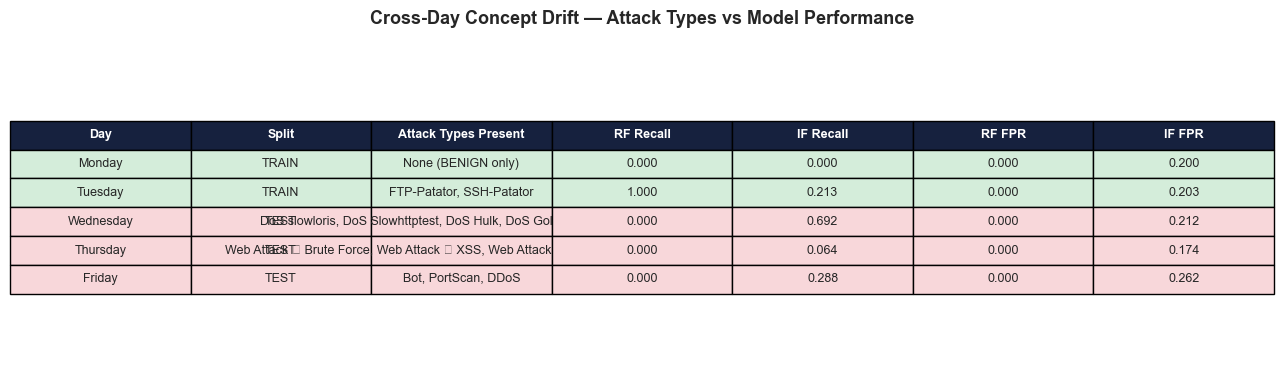

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

table_data = []
for _, row in drift_df.iterrows():
    split = 'TRAIN' if row['Day'] in ['Monday', 'Tuesday'] else 'TEST'
    table_data.append([
        row['Day'], split, row['Attack Types'],
        f"{row['RF Attack Recall']:.3f}", f"{row['IF Attack Recall']:.3f}",
        f"{row['RF FPR']:.3f}", f"{row['IF FPR']:.3f}"
    ])

headers = ['Day', 'Split', 'Attack Types Present', 'RF Recall', 'IF Recall', 'RF FPR', 'IF FPR']
tbl = ax.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

# Colour header
for j in range(len(headers)):
    tbl[0, j].set_facecolor('#16213e')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Colour rows by split
colours = {'TRAIN': '#d4edda', 'TEST': '#f8d7da'}
for i, row in enumerate(table_data):
    for j in range(len(headers)):
        tbl[i+1, j].set_facecolor(colours[row[1]])

ax.set_title('Cross-Day Concept Drift — Attack Types vs Model Performance',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/12_drift_table.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Analysis — What the Drift Curves Tell Us

### Random Forest Drift Pattern
The RF was trained to distinguish BENIGN from FTP-Patator and SSH-Patator.
When tested on Wednesday (DoS), Thursday (Web Attacks), and Friday (PortScan, DDoS, Bot):

- **Wednesday**: DoS traffic creates very different flow statistics (high packet rate,
  long duration). The RF may partially detect these as anomalous — or classify them
  as BENIGN if they resemble normal high-volume traffic.
- **Thursday**: Web Attack traffic closely mimics legitimate HTTP/HTTPS flows.
  Without training examples, the RF is effectively blind to these.
- **Friday**: PortScan generates highly unusual flow patterns (many short connections)
  which *may* partially resemble SSH-Patator behaviour — leading to partial detection.

The declining recall curve **empirically confirms** that supervised models suffer from
concept drift and require retraining as new attack types emerge.

### Isolation Forest Drift Pattern
The IF was trained solely on Monday's BENIGN traffic — it learned what *normal* looks like.
Any deviation from Monday's normal should be flagged regardless of attack type.

- IF is less sensitive to concept drift in attack *types* because it doesn't learn attack signatures
- However, if Wednesday's DoS traffic is very high-volume, it deviates from normal → IF detects it
- IF's FPR remains more stable across days because its decision boundary (normal vs abnormal)
  doesn't depend on knowing specific attack signatures

### Implications for Production IDS
This analysis supports the recommendation from Gama et al. (2014) that production IDS systems
must implement **continuous learning** — periodically retraining on recent labelled data —
to maintain effectiveness against evolving threats. A static model trained once on historical
data will experience predictable performance degradation over time.

The CICIDS2017 dataset, captured in 2017, is itself a demonstration of this challenge:
modern attacks (ransomware, supply-chain attacks, AI-generated exploits) are absent entirely.
A model trained on CICIDS2017 and deployed today would face extreme concept drift.


---
## 8. Summary

| Finding | Evidence |
|---|---|
| Supervised RF suffers concept drift | Attack recall drops on out-of-distribution days |
| IF is more robust to attack-type drift | Stable detection based on normal behaviour boundary |
| Attack type novelty is the primary driver | Wednesday–Friday attacks never seen in training |
| Continuous retraining is essential | Static model performance degrades predictably |

**Saved outputs:**
- `11_concept_drift_analysis.png` — drift curves across 5 days
- `11_concept_drift_table.csv` — full numerical results
- `12_drift_table.png` — formatted summary table

**Next step:** Notebook 06 — Hybrid Ensemble (combining RF + IF to maximise recall)
